In [1]:
from sorbetto.tile import ValueTile, WorstTile, BestTile
from sorbetto.flavor import ValueFlavor, WorstFlavor, BestFlavor
from sorbetto.parameterization import ParameterizationDefault
from sorbetto.performance import TwoClassClassificationPerformance
from sorbetto.performance import FiniteSetOfTwoClassClassificationPerformances
from sorbetto.annotation.annotation_isovalue_curves import AnnotationIsovalueCurves
from sorbetto.annotation.annotation_text import AnnotationText
from sorbetto.annotation.annotation_geometric import AnnotationGeometric
from sorbetto.annotation.annotation_frontiers_between_rankings import AnnotationFrontiersBetweenRankings
from sorbetto.ranking import RankingScore

import matplotlib.pyplot as plt

In [2]:
def show_value_tile ( ptn, pfp, pfn, ptp ) :
    performance = TwoClassClassificationPerformance ( ptn, pfp, pfn, ptp, name="my performance" )
    flavor = ValueFlavor ( performance, name="Value Flavor" )
    
    parameterization = ParameterizationDefault ()
    tile = ValueTile (parameterization, flavor)
    annotation = AnnotationIsovalueCurves ()
    tile.appendAnnotation ( annotation )
    for score in [
        RankingScore.getTrueNegativeRate (),
        RankingScore.getTruePositiveRate (),
        RankingScore.getF ( beta=0.5 ),
        RankingScore.getF ( beta=1.0 ),
        RankingScore.getF ( beta=2.0 ),
        RankingScore.getAccuracy (),
        RankingScore.getNegativePredictiveValue (),
        RankingScore.getPositivePredictiveValue ()
    ] :
        annotation = AnnotationText ( score, score.shortLabel )
        tile.appendAnnotation ( annotation )
    try :
        annotation = AnnotationGeometric ( tile.getPencil () )
        tile.appendAnnotation ( annotation ) # TODO: is this working ???
    except :
        pass
    tile.draw ()
    plt.show ()
    print ( tile.getExplanation () )

In [3]:
def show_roc ( ptn, pfp, pfn, ptp ) :
    performance = TwoClassClassificationPerformance ( ptn, pfp, pfn, ptp, name="my performance" )
    
    fig, ax = plt.subplots () # TODO: remove this
    performance.drawInROC (fig, ax)
    plt.show ()

In [4]:
def show_worst_tile ( ptn, pfp, pfn, ptp ) :
    performance = TwoClassClassificationPerformance ( ptn, pfp, pfn, ptp, name="my performance" )
    performance_opp = TwoClassClassificationPerformance ( pfp, ptn, ptp, pfn, name="opposite performance" )
    performance_neg = TwoClassClassificationPerformance ( ptn+pfp, 0.0, pfn+ptp, 0.0, name="predict neg" )
    performance_pos = TwoClassClassificationPerformance ( 0.0, ptn+pfp, 0.0, pfn+ptp, name="predict pos" )
    performances = [ performance, performance_opp, performance_neg, performance_pos ]
    performances = FiniteSetOfTwoClassClassificationPerformances ( performances )
    flavor = WorstFlavor ( performances=performances, entity_list=[] )
    
    parameterization = ParameterizationDefault ()
    tile = WorstTile (parameterization, flavor)
    annotation = AnnotationIsovalueCurves ()
    tile.appendAnnotation ( annotation )
    for score in [
        RankingScore.getTrueNegativeRate (),
        RankingScore.getTruePositiveRate (),
        RankingScore.getF ( beta=0.5 ),
        RankingScore.getF ( beta=1.0 ),
        RankingScore.getF ( beta=2.0 ),
        RankingScore.getAccuracy (),
        RankingScore.getNegativePredictiveValue (),
        RankingScore.getPositivePredictiveValue ()
    ] :
        annotation = AnnotationText ( score, score.shortLabel )
        tile.appendAnnotation ( annotation )
    annotation = AnnotationFrontiersBetweenRankings ( performances )
    tile.appendAnnotation ( annotation )
    tile.draw ()
    plt.show ()
    print ( tile.getExplanation () )

In [5]:
def show_best_tile ( ptn, pfp, pfn, ptp ) :
    performance = TwoClassClassificationPerformance ( ptn, pfp, pfn, ptp, name="my performance" )
    performance_opp = TwoClassClassificationPerformance ( pfp, ptn, ptp, pfn, name="opposite performance" )
    performance_neg = TwoClassClassificationPerformance ( ptn+pfp, 0.0, pfn+ptp, 0.0, name="predict neg" )
    performance_pos = TwoClassClassificationPerformance ( 0.0, ptn+pfp, 0.0, pfn+ptp, name="predict pos" )
    performances = [ performance, performance_opp, performance_neg, performance_pos ]
    performances = FiniteSetOfTwoClassClassificationPerformances ( performances )
    flavor = BestFlavor ( performances=performances, entity_list=[] )
    
    parameterization = ParameterizationDefault ()
    tile = BestTile (parameterization, flavor)
    annotation = AnnotationIsovalueCurves ()
    tile.appendAnnotation ( annotation )
    for score in [
        RankingScore.getTrueNegativeRate (),
        RankingScore.getTruePositiveRate (),
        RankingScore.getF ( beta=0.5 ),
        RankingScore.getF ( beta=1.0 ),
        RankingScore.getF ( beta=2.0 ),
        RankingScore.getAccuracy (),
        RankingScore.getNegativePredictiveValue (),
        RankingScore.getPositivePredictiveValue ()
    ] :
        annotation = AnnotationText ( score, score.shortLabel )
        tile.appendAnnotation ( annotation )
    annotation = AnnotationFrontiersBetweenRankings ( performances )
    tile.appendAnnotation ( annotation )
    tile.draw ()
    plt.show ()
    print ( tile.getExplanation () )

In [6]:
def do_all ( ptn, pfp, pfn, ptp ) :
    show_value_tile ( ptn, pfp, pfn, ptp ) 
    show_roc ( ptn, pfp, pfn, ptp )
    show_worst_tile ( ptn, pfp, pfn, ptp )
    show_best_tile ( ptn, pfp, pfn, ptp )

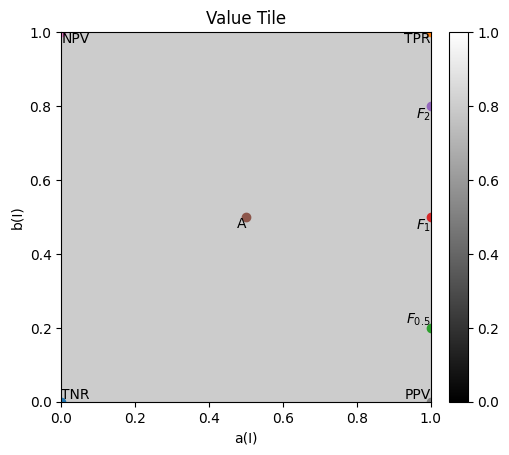

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.4, 0.1, 0.1, 0.4), with the parameterization 'default'. This Tile is constant. This is because it is a very particular case in which the probabilities of a true negative and of a true positive are equal and the probabilities of a false positive and of a false negative are also equal. In other words, both class priors are equal to 0.5 and the classifier is unbiased (the opposite classifier is also unbiased). The value taken by all canonical ranking scores is 0.8.


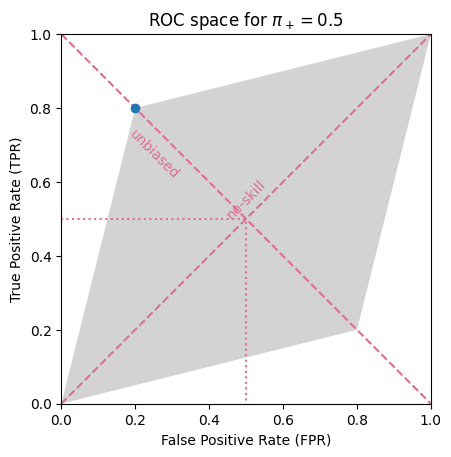

/Users/pierard/Documents/GitHub/sorbetto/examples/sorbetto/ranking/ranking_score.py:394: RuntimeWarning: invalid value encountered in divide
  return satisfying / (satisfying + unsatisfying)


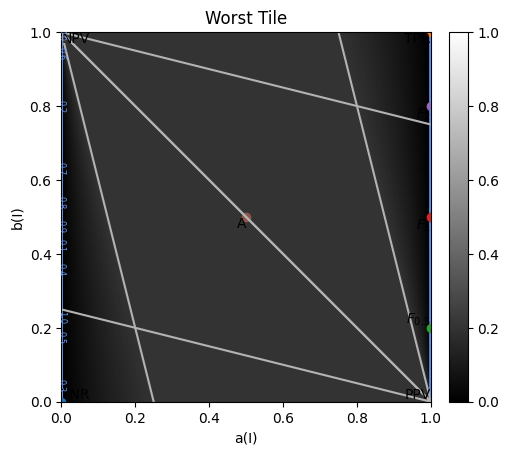

Explanation for this tile is not implemented yet


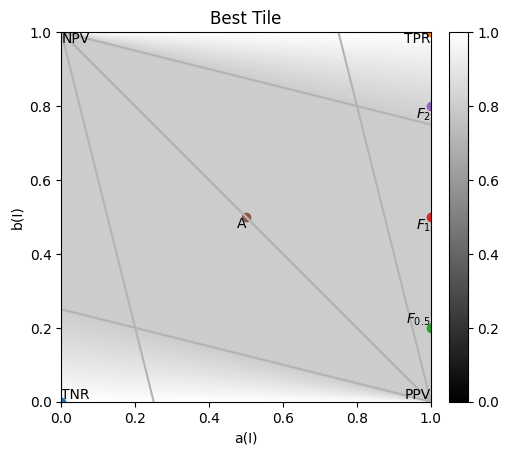

Explanation for this tile is not implemented yet


In [7]:
do_all ( 0.4, 0.1, 0.1, 0.4 )

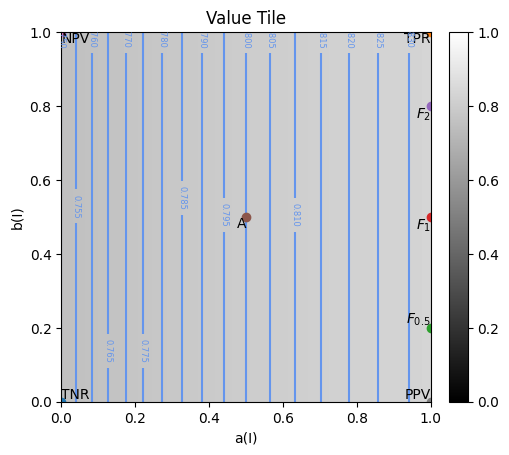

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.3, 0.1, 0.1, 0.5), with the parameterization 'default'. The value taken by canonical ranking scores is between 0.7499999999999999 and 0.8333333333333334. The mean value over the Tile, called 'Volume Under Tile (VUT) with the default parameterization, is equal to 0.7972674459459179 (be careful as the score VUT cannot be used to rank). This Tile does not show any vertical variation. This is because it is a very particular case in which the probabilities of a  false positive and of a false negative are equal. As the probability of a true negative is lower than the probability of a true positive, the value taken by the canonical ranking scores is minimized at the left of the Tile, where no importance is given to the true positives and is maximized at the right of the Tile, where no importance is given to th

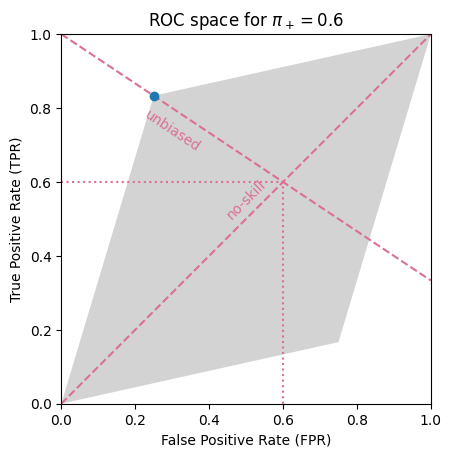

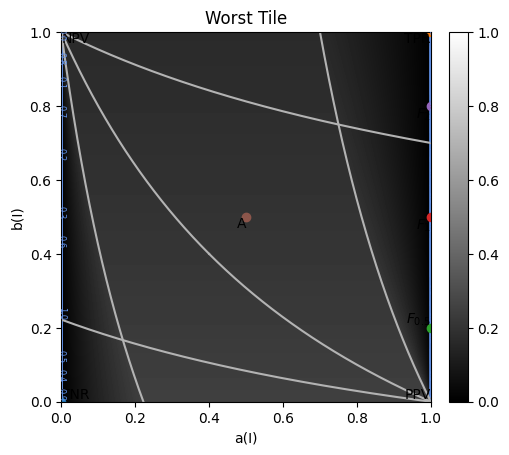

Explanation for this tile is not implemented yet


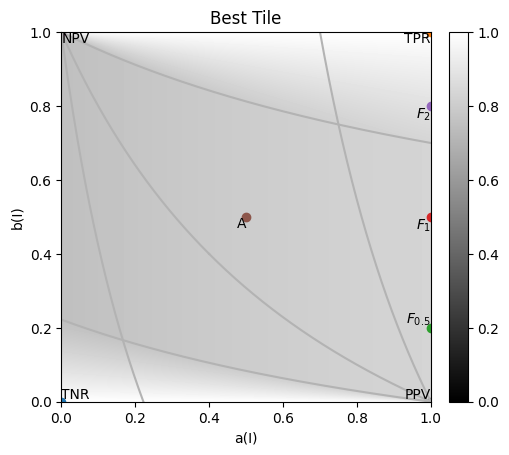

Explanation for this tile is not implemented yet


In [8]:
do_all ( 0.3, 0.1, 0.1, 0.5 )

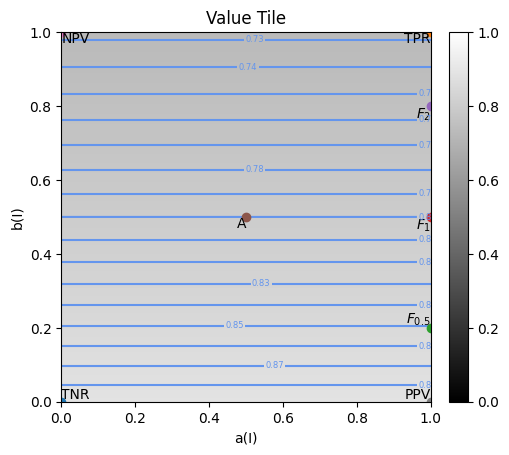

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.4, 0.05, 0.15, 0.4), with the parameterization 'default'. The value taken by canonical ranking scores is between 0.7272727272727273 and 0.888888888888889. The mean value over the Tile, called 'Volume Under Tile (VUT) with the default parameterization, is equal to 0.8026827818486051 (be careful as the score VUT cannot be used to rank). This Tile does not show any horizontal variation. This is because it is a very particular case in which the probabilities of a  true negative and of a true positive are equal. As the probability of a false negative is higher than the probability of a false positive, the value taken by the canonical ranking scores is minimized at the top of the Tile, where no importance is given to the false positives and is maximized at the bottom of the Tile, where no importance is given 

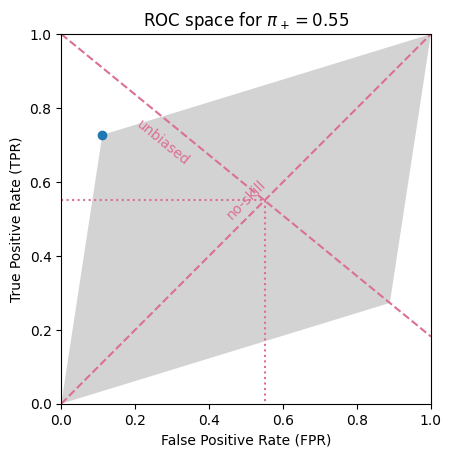

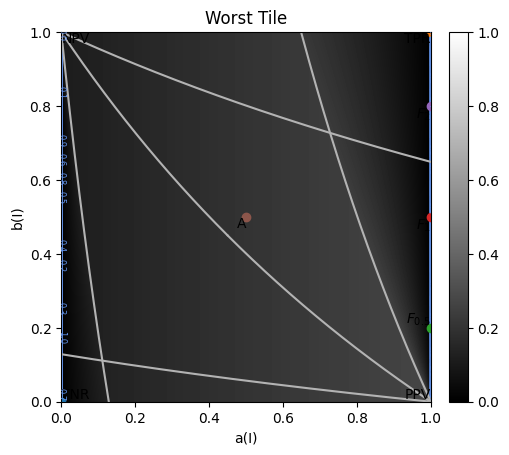

Explanation for this tile is not implemented yet


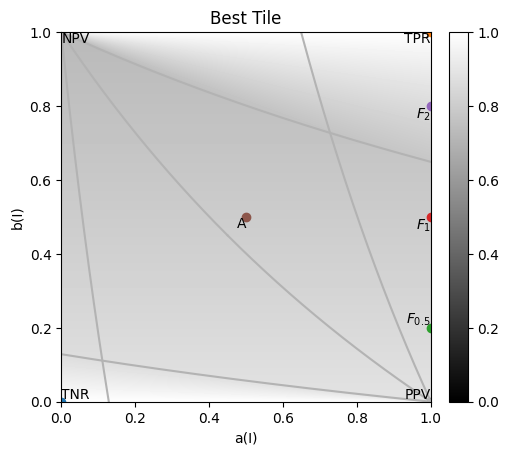

Explanation for this tile is not implemented yet


In [9]:
do_all ( 0.4, 0.05, 0.15, 0.4 )

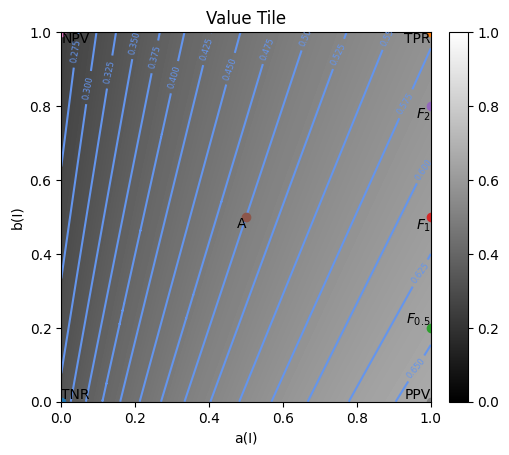

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.1, 0.2, 0.3, 0.4), with the parameterization 'default'. The value taken by canonical ranking scores is between 0.25 and 0.6666666666666666. The mean value over the Tile, called 'Volume Under Tile (VUT) with the default parameterization, is equal to 0.45738771780266346 (be careful as the score VUT cannot be used to rank). With the parameterization 'default parameterization', the canonical ranking scores that take any given value are aligned, and these lines form a pencil whose vertex is located at (0.3333333333333333, -2.0000000000000004).


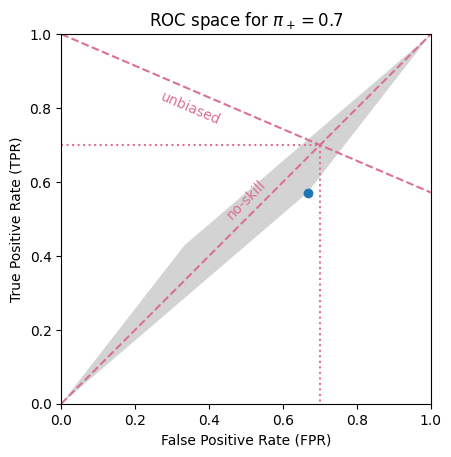

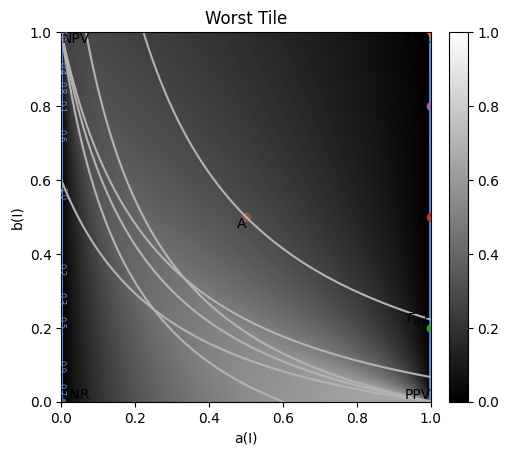

Explanation for this tile is not implemented yet


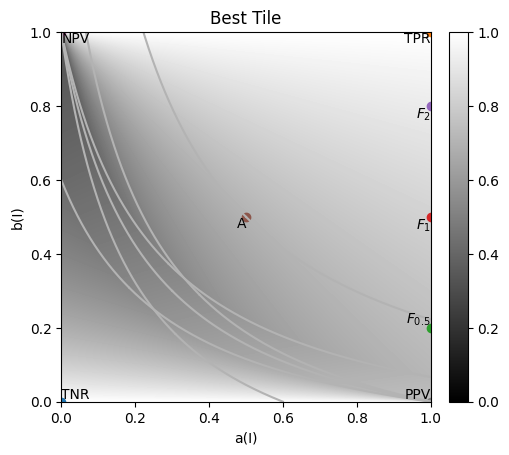

Explanation for this tile is not implemented yet


In [10]:
do_all ( 0.1, 0.2, 0.3, 0.4 )